In [1]:
import sys
import time
import random
import numpy as np
import pandas as pd
from functools import partial
import matplotlib.pyplot as plt
import pennylane as qp
import pennylane.labs.estimator_beta as qre

In [1]:
# Allows for installing development versions of pennylane (0.46.0b1)
!{sys.executable} -m pip install --upgrade --pre pennylane

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 22.3 MB/s  0:00:004.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 940.0/940.0 kB 30.1 MB/s  0:00:00
  Attempting uninstall: autoray
    Found existing installation: autoray 0.8.4
    Uninstalling autoray-0.8.4:
      Successfully uninstalled autoray-0.8.4
  Attempting uninstall: pennylane
    Found existing installation: pennylane 0.45.1
    Uninstalling pennylane-0.45.1:
      Successfully uninstalled pennylane-0.45.138;5;237m╺━━━━━━━━━━━━━━━━━━━ 1/2 [pennylane]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pennylane]━ 1/2 [pennylane]


### Debugging Issues with Importing labs.estimator_beta

In [3]:
import importlib
importlib.import_module("pennylane.labs")
importlib.import_module("pennylane.labs.estimator_beta")

<module 'pennylane.labs.estimator_beta' from '/opt/anaconda3/envs/quantum/lib/python3.12/site-packages/pennylane/labs/estimator_beta/__init__.py'>

In [26]:
import traceback

try:
    import pennylane.labs.estimator_beta as qre
except Exception:
    traceback.print_exc()

In [4]:
import pkgutil
import pennylane

[m.name for m in pkgutil.iter_modules(pennylane.__path__)]

['_class_property',
 '_entry_points_utils',
 '_grad',
 '_version',
 'about',
 'allocation',
 'boolean_fn',
 'bose',
 'capture',
 'circuit_graph',
 'compiler',
 'concurrency',
 'configuration',
 'control_flow',
 'core',
 'data',
 'debugging',
 'decomposition',
 'devices',
 'drawer',
 'estimator',
 'exceptions',
 'fermi',
 'fourier',
 'ftqc',
 'gradients',
 'io',
 'kernels',
 'labs',
 'liealg',
 'logging',
 'math',
 'measurements',
 'noise',
 'numpy',
 'operation',
 'ops',
 'optimize',
 'pauli',
 'pulse',
 'pytrees',
 'qaoa',
 'qchem',
 'qcut',
 'qnn',
 'queuing',
 'registers',
 'resource',
 'shadows',
 'spin',
 'tape',
 'templates',
 'transforms',
 'typing',
 'wires',
 'workflow']

In [5]:
for x in dir(qre):
    if "QROM" in x:
        print(x)

LabsQROM
QROM
QROMStatePreparation
SelectCopyQROM


In [18]:
print(qp.__file__)

/opt/anaconda3/envs/quantum/lib/python3.12/site-packages/pennylane/__init__.py


In [8]:
!{sys.executable} -m pip install jax jaxlib

  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 34.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 MB 29.1 MB/s  0:00:02a 0:00:010:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.4/565.4 kB 11.7 MB/s  0:00:00
Using cached opt_einsum-3.4.0-py3-none-any.whl (71 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [jax]━━━━━━━ 3/4 [jax]ib]


In [10]:
# Version Verification Cell
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PennyLane:", qp.__version__)

Python: 3.12.2
NumPy: 2.5.3
Pandas: 3.0.6
PennyLane: 0.45.1


Source: https://pennylane.ai/blog/2026/05/halving-the-cost-of-qrom

PennyLane repo: https://github.com/PennyLaneAI/pennylane/blob/main/pennylane/__init__.py

### SelectSwap

In [2]:
def gates_MultiControlledX(k):

    if k == 0: return 0, 0, 0
    wires = list(range(k + 1))  # k controls + 1 target

    @partial(qp.compile, basis_set="CNOT")
    @qp.qnode(qp.device("default.qubit"))
    def circuit():
        qp.MultiControlledX(wires=wires)
        return qp.state()

    r = qp.specs(circuit)()["resources"]
    return r.gate_sizes.get(1, 0), r.gate_sizes.get(2, 0), r.depth

In [3]:
def estimate_gates(num_index_bits, num_swap_bits=0, bits_per_value=2):

    num_select_bits = num_index_bits - num_swap_bits

    oneQ_mcx, twoQ_mcx, _ = gates_MultiControlledX(num_select_bits)
    oneQ_ccx, twoQ_ccx, _ = gates_MultiControlledX(2)
    
    oneQ_select_lines = oneQ_mcx * bits_per_value * 2**num_select_bits
    oneQ_idx_switching = 2**(num_index_bits) - 1 # sum(2**x for x in range(num_idx_its + 1))
    oneQ_swap_lines = oneQ_ccx * bits_per_value * (2**num_swap_bits - 1)
    
    oneQ = oneQ_select_lines + oneQ_idx_switching + oneQ_swap_lines

    # Deal with teh num_select bits.
    twoQ_select_lines = twoQ_mcx * bits_per_value * 2**num_index_bits
    twoQ_swap_lines = (twoQ_ccx + 2) * bits_per_value * (2**num_swap_bits - 1) # Add 2 for the 2 CNOTs for the CSWAP
    twoQ = twoQ_select_lines + twoQ_swap_lines
    
    # print(f"{twoQ_mcx, bits_per_value, num_select_bits}")
    print(f"Estimated 1Q Gates: {oneQ}")
    print(f"Estimated 2Q Gates: {twoQ}")


In [4]:
def analyze_qrom(num_index_bits, num_swap_bits=0, bits_per_value=2, print_out=True, worstcase=False):
    
    def generate_bitstrings(array_length, bit_length):
        return [f"{random.randint(0, 2**bit_length - 1):0{bit_length}b}" for _ in range(array_length)]
    
    def worst(array_length, bit_length):
        return [f"{2**bit_length - 1:0{bit_length}b}" for _ in range(array_length)]
    
    bitstrings = generate_bitstrings(2**num_index_bits, bits_per_value)
    if worst: bitstrings = worst(2**num_index_bits, bits_per_value)
    
    control_wires = np.arange(num_index_bits)
    target_wires  = np.arange(num_index_bits, num_index_bits + bits_per_value)
    work_wires    = np.arange(target_wires[-1] + 1, target_wires[-1] + 1 + bits_per_value*(2**num_swap_bits - 1))
    
    @partial(qp.compile, basis_set="CNOT")  # Line added for resource estimation purposes only.
    @qp.set_shots(1)
    @qp.qnode(qp.device("default.qubit"))
    def circuit(index):
        qp.BasisState(index, wires=control_wires)
        qp.QROM(bitstrings, control_wires, target_wires, work_wires, clean=False)
        return qp.sample(wires=target_wires), qp.sample(wires=target_wires)
    
    r = qp.specs(circuit)(0)["resources"]

    num_qubits = len(control_wires) + len(target_wires) + len(work_wires)
    oneQ = r.gate_sizes.get(1,0)
    twoQ = r.gate_sizes.get(2,0)

    if print_out:
        print("Number of qubits: ", num_qubits)
        print("One-qubit gates: ", oneQ)
        print("Two-qubit gates: ", twoQ)
        print(f"Depth: {r.depth}")

    return num_qubits, oneQ, twoQ, r.depth

In [5]:
def draw_qrom(num_index_bits, num_swap_bits=0, bits_per_value=2, worstcase=False, detail=2):
    
    def generate_bitstrings(array_length, bit_length):
        return [f"{random.randint(0, 2**bit_length - 1):0{bit_length}b}" for _ in range(array_length)]

    def worst(array_length, bit_length):
        return [f"{2**bit_length - 1:0{bit_length}b}" for _ in range(array_length)]
    
    bitstrings = generate_bitstrings(2**num_index_bits, bits_per_value)
    if worst: bitstrings = worst(2**num_index_bits, bits_per_value)
    
    control_wires = np.arange(num_index_bits)
    target_wires  = np.arange(num_index_bits, num_index_bits + bits_per_value)
    work_wires    = np.arange(target_wires[-1] + 1, target_wires[-1] + 1 + bits_per_value*(2**num_swap_bits - 1))
    
    # Line added for drawing purposes only
    @partial(qp.transforms.decompose, max_expansion=detail)
    @qp.set_shots(1)
    @qp.qnode(qp.device("default.qubit"))
    def circuit(index):
        qp.BasisState(index, wires=control_wires)
        qp.QROM(bitstrings, control_wires, target_wires, work_wires, clean=False)
        return qp.sample(wires=target_wires), qp.sample(wires=target_wires)
    
    qp.draw_mpl(circuit, style="pennylane")(0)
    plt.show()

In [3]:
analyze_qrom(3, 2, 3, worstcase=True)

Number of qubits:  15
One-qubit gates:  119
Two-qubit gates:  96
Depth: 93


(15, 119, 96, 93)

Matplotlib is building the font cache; this may take a moment.


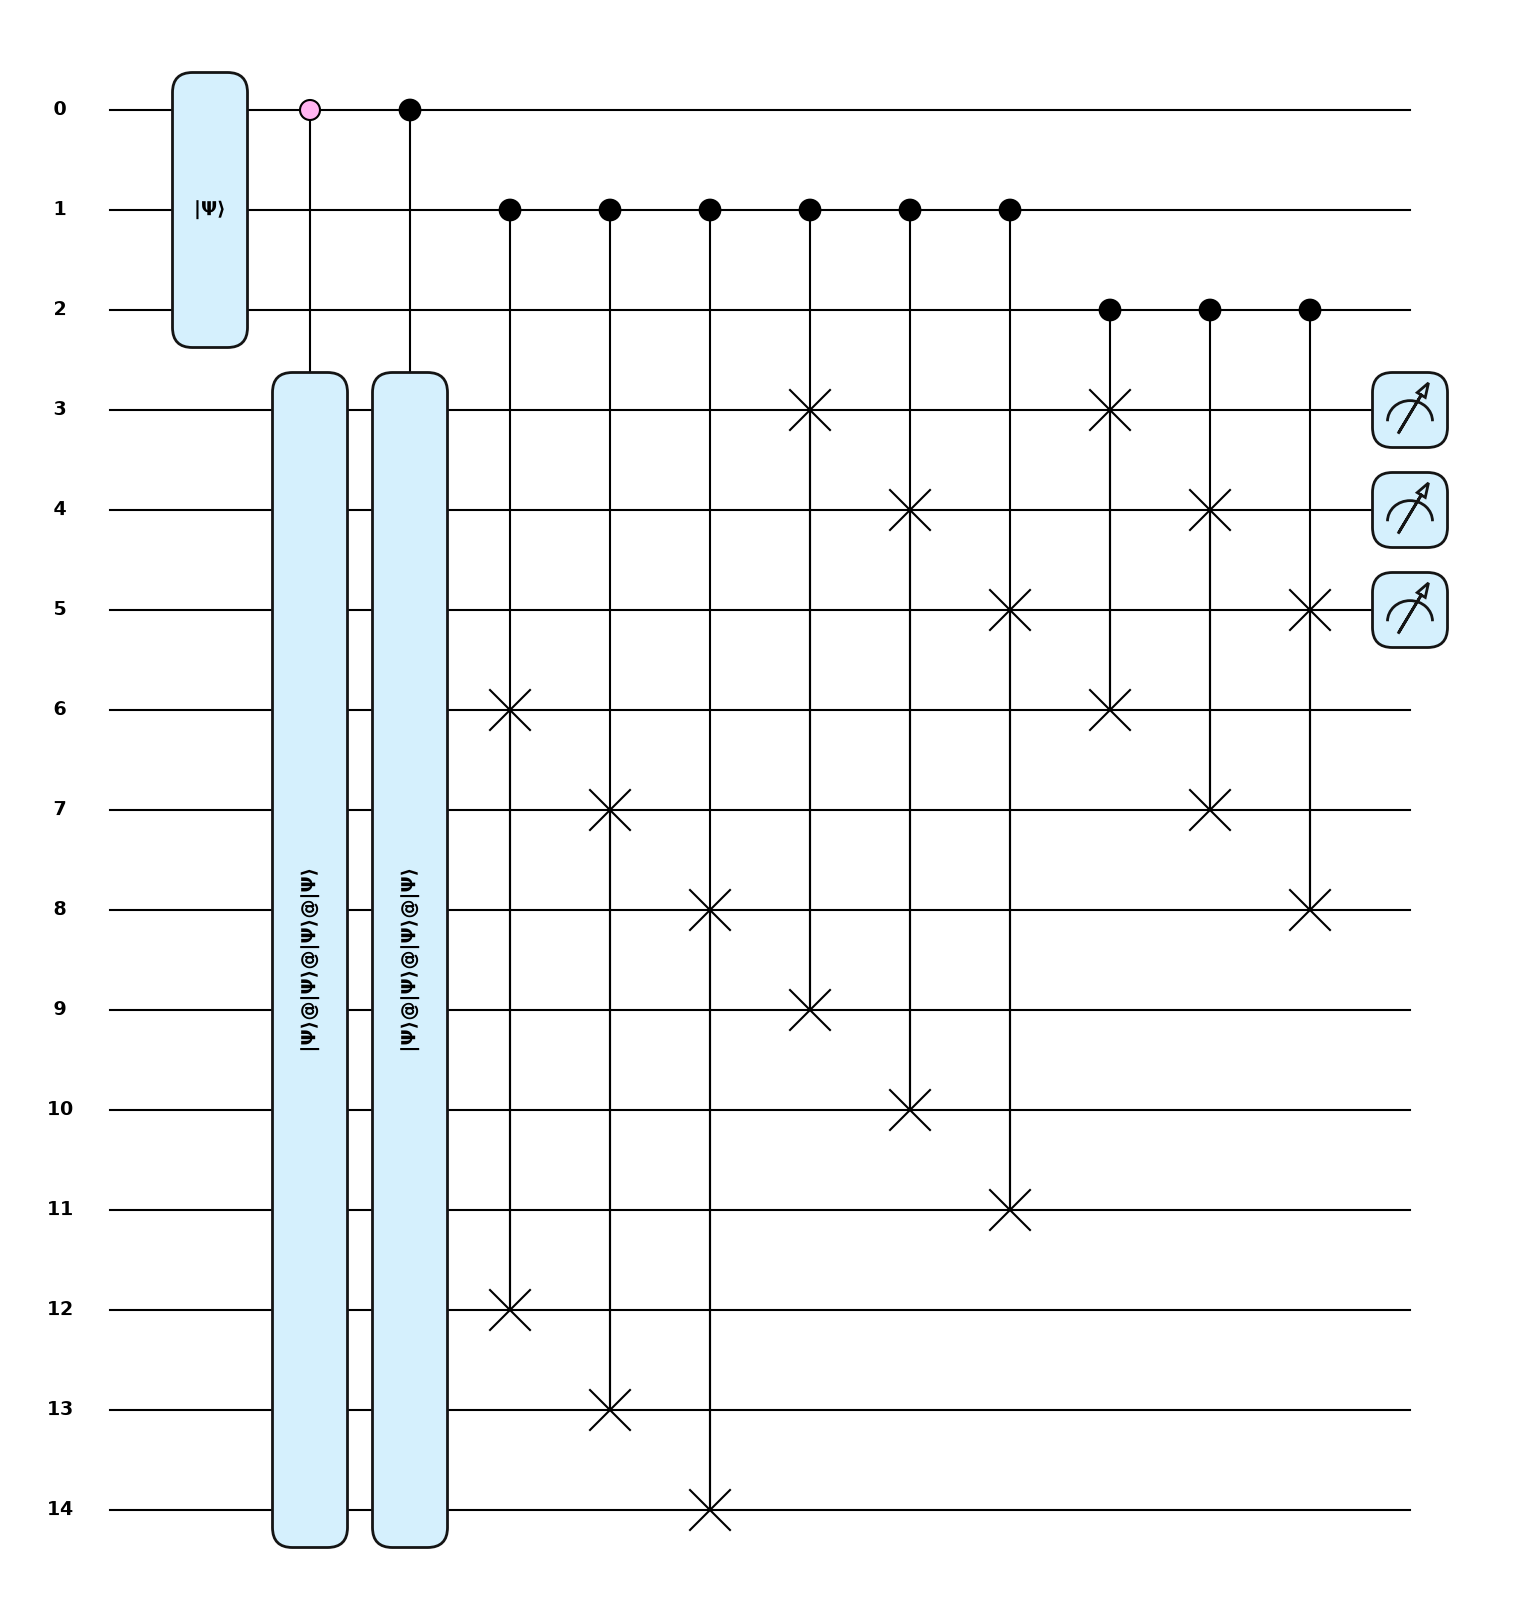

In [12]:
draw_qrom(3, 2, 3, worstcase=True)

In [6]:
estimate_gates(3, 2, 3)

Estimated 1Q Gates: 124
Estimated 2Q Gates: 96


In [25]:
import pennylane.estimator as est

[x for x in dir(est) if "estimate" in x]

['estimate', 'estimate_error', 'estimate_shots']

In [70]:
import pennylane.estimator as qre

def estimate_qrom(num_index_bits, num_swap_bits=0, bits_per_value=2, print_out=True, worstcase=False):
    N = 2**num_index_bits
    b = bits_per_value

    if worstcase: num_bit_flips = N * b
    else: num_bit_flips = (N * b) // 2

    # select_swap_depth = None if num_swap_bits == 0 else 2**num_swap_bits
    select_swap_depth = 2**(25)
    
    qrom = qre.QROM(
        num_bitstrings=N,
        size_bitstring=b,
        num_bit_flips=num_bit_flips,
        restored=False,
        select_swap_depth=select_swap_depth,
    )

    res = qre.estimate(qrom)

    oneQ_ccx, twoQ_ccx, depth_ccx = gates_MultiControlledX(2)

    counts = res.gate_counts

    # Adjust keys if needed after printing counts
    n_toffoli = counts.get("Toffoli", 0)
    n_x = counts.get("X", 0)
    n_h = counts.get("Hadamard", 0)
    n_cnot = counts.get("CNOT", 0)

    oneQ = oneQ_ccx * n_toffoli + n_x + n_h
    twoQ = twoQ_ccx * n_toffoli + n_cnot

    num_qubits = res.total_wires

    if print_out:
        print("Number of qubits:", num_qubits)
        print("One-qubit gates:", oneQ)
        print("Two-qubit gates:", twoQ)

    return num_qubits, oneQ, twoQ

In [9]:
analyze_qrom(3, 2, 3, worstcase=True)

Number of qubits:  15
One-qubit gates:  119
Two-qubit gates:  96
Depth: 93


(15, 119, 96, 93)

In [62]:
analyze_qrom(6, 5, 4, worstcase=True)

Number of qubits:  134
One-qubit gates:  1614
Two-qubit gates:  1248
Depth: 777


(134, 1614, 1248, 777)

In [71]:
estimate_qrom(6, 5, 4, worstcase=True);

Number of qubits: 262
One-qubit gates: 3784
Two-qubit gates: 2016


--- Resources: ---
 Total wires: 25
   algorithmic wires: 10
   allocated wires: 15
     zero state: 15
     any state: 0
 Total gates : 417
   'Toffoli': 26,
   'CNOT': 308,
   'X': 41,
   'Hadamard': 42
--- Resources: ---
 Total wires: 18
   algorithmic wires: 10
   allocated wires: 8
     zero state: 8
     any state: 0
 Total gates : 513
   'Toffoli': 34,
   'CNOT': 324,
   'X': 65,
   'Hadamard': 90
--- Resources: ---
 Total wires: 25
   algorithmic wires: 10
   allocated wires: 15
     zero state: 15
     any state: 0
 Total gates : 417
   'Toffoli': 26,
   'CNOT': 308,
   'X': 41,
   'Hadamard': 42
--- Resources: ---
 Total wires: 40
   algorithmic wires: 10
   allocated wires: 30
     zero state: 30
     any state: 0
 Total gates : 417
   'Toffoli': 34,
   'CNOT': 324,
   'X': 41,
   'Hadamard': 18
--- Resources: ---
 Total wires: 71
   algorithmic wires: 10
   allocated wires: 61
     zero state: 61
     any state: 0
 Total gates : 513
   'Toffoli': 62,
   'CNOT': 380,
   'X':

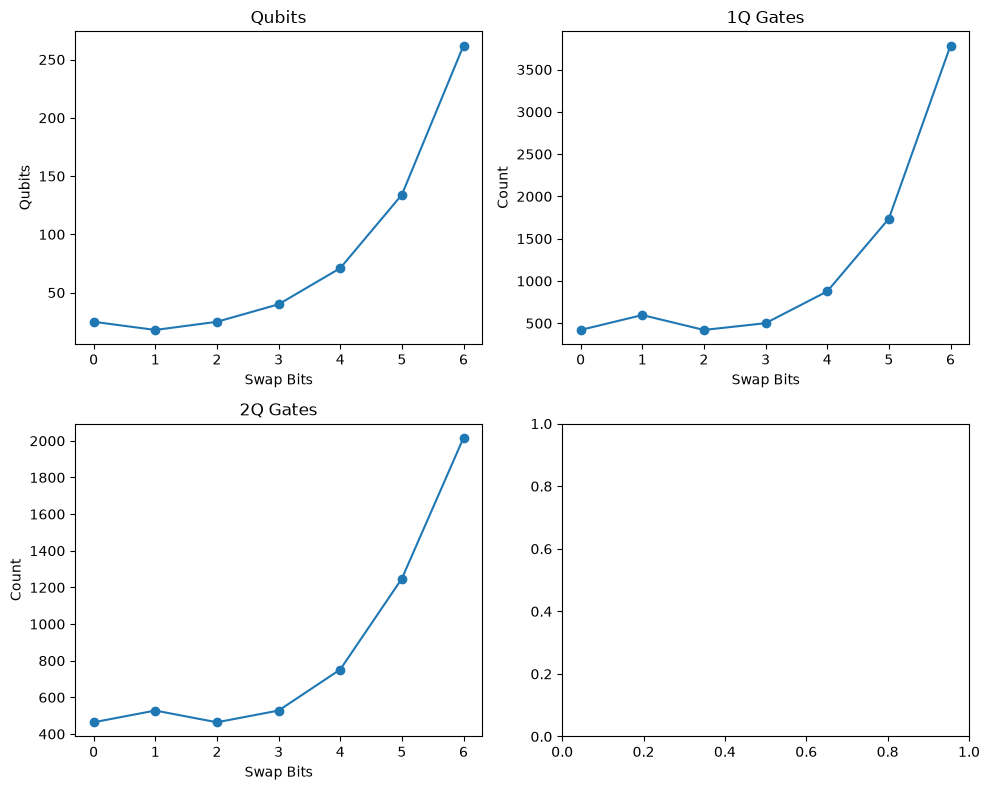

In [53]:
import matplotlib.pyplot as plt

swap_bits = list(range(7))

qubits = []
oneQs = []
twoQs = []

for s in swap_bits:
    n_qubits, oneQ, twoQ = estimate_qrom(
        num_index_bits=6,
        num_swap_bits=s,
        bits_per_value=4,
        worstcase=True,
        print_out=False
    )

    qubits.append(n_qubits)
    oneQs.append(oneQ)
    twoQs.append(twoQ)

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0,0].plot(swap_bits, qubits, marker='o')
axs[0,0].set_title("Qubits")
axs[0,0].set_xlabel("Swap Bits")
axs[0,0].set_ylabel("Qubits")

axs[0,1].plot(swap_bits, oneQs, marker='o')
axs[0,1].set_title("1Q Gates")
axs[0,1].set_xlabel("Swap Bits")
axs[0,1].set_ylabel("Count")

axs[1,0].plot(swap_bits, twoQs, marker='o')
axs[1,0].set_title("2Q Gates")
axs[1,0].set_xlabel("Swap Bits")
axs[1,0].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [23]:
252*6+504

2016

In [24]:
252*13+508

3784

In [20]:
10+13*9

127

In [18]:
estimate_qrom(3, 2, 3, worstcase=True);

Toffoli: (13, 6, 14)
--- Resources: ---
 Total wires: 15
   algorithmic wires: 6
   allocated wires: 9
     zero state: 9
     any state: 0
 Total gates : 61
   'Toffoli': 9,
   'CNOT': 42,
   'X': 10,
   'Hadamard': 0


In [37]:
import pennylane.estimator as est
qrom = est.QROM(bitstrings, control_wires, target_wires, work_wires, clean=False)

<module 'pennylane.labs.estimator_beta.templates' from '/opt/anaconda3/envs/quantum/lib/python3.12/site-packages/pennylane/labs/estimator_beta/templates/__init__.py'>

### SelectCopy Architecture
Select-Copy QROM Investigation

Recent literature suggests that the Select-Copy QROM architecture can provide theoretical advantages over Select-Swap QROM by reducing certain fault-tolerant resource requirements through the use of dirty auxiliary qubits and optimized data-loading procedures. The PennyLane implementation exposes similar high-level design parameters as the existing Select-Swap approach, including the number of index bits, the number of bits per stored value, and the amount of auxiliary workspace available for parallel loading. This makes Select-Copy a promising candidate for future optimization studies and direct comparison against Select-Swap architectures.

However, during implementation, it was determined that the current PennyLane SelectCopyQROM class is intended solely for resource estimation rather than circuit execution. The class inherits from PennyLane's resource-estimation framework and provides symbolic decompositions consisting of gate counts, ancilla allocation information, and fault-tolerant resource estimates. While it can generate metrics such as logical qubit count, Toffoli count, T-count, and estimated depth, it does not contain the wire-level information required to construct, visualize, or simulate an executable quantum circuit. Consequently, fidelity measurements and statevector simulations cannot currently be performed using the provided Select-Copy implementation.

For this reason, all practical experimentation in this work was performed using the existing Select-Swap QROM implementation, which is fully executable within PennyLane and supports circuit simulation, resource extraction, and fidelity analysis. The reinforcement learning optimization framework was therefore developed around the Select-Swap architecture as the current deployable solution.

To maintain future compatibility, the reinforcement learning environment was designed to be modular and parameterized by the same fundamental QROM characteristics used by both approaches, namely the number of index bits, bits per value, and auxiliary workspace allocation. As a result, the optimization framework remains scalable and plug-and-play. Once a fully executable Select-Copy QROM implementation becomes available, it can be integrated into the existing workflow with minimal modification, enabling direct comparison of resource efficiency, depth, and fidelity between Select-Swap and Select-Copy architectures.

In [21]:
def analyze_copy_qrom(num_index_bits, num_swap_bits=0, bits_per_value=2, print_out=True):
    qrom = qre.SelectCopyQROM(
        num_bitstrings=2**num_index_bits,
        size_bitstring=bits_per_value,
        available_dirty_aux=bits_per_value * (2**num_swap_bits - 1)
    )

    res = qre.estimate(qrom)

    if print_out:
        print(res)

    return res

The SelectCopyQROM resource estimator depends only on the number of stored entries, bitstring length, and available auxiliary qubits. Unlike the executable SelectSwap implementation, the estimator does not accept the underlying data values as input. Consequently, resource estimates are independent of the specific bit patterns stored in the QROM and represent a worst-case or generic QROM instance of the specified dimensions.

In [22]:
analyze_copy_qrom(3, 2, 3);

--- Resources: ---
 Total wires: 8
   algorithmic wires: 6
   allocated wires: 2
     zero state: 2
     any state: 0
 Total gates : 75
   'Toffoli': 8,
   'CNOT': 36,
   'X': 16,
   'Hadamard': 15


In [8]:
for x in dir(qre):
    if "decomp" in x:
        print(x)

aqft_resource_decomp
ch_resource_decomp
ch_toffoli_based_resource_decomp
hadamard_controlled_resource_decomp
hadamard_toffoli_based_controlled_decomp
mcx_many_clean_aux_resource_decomp
mcx_one_clean_aux_resource_decomp
mcx_one_dirty_aux_resource_decomp
paulirot_controlled_resource_decomp
qft_phase_grad_resource_decomp
qrom_state_preparation_phase_grad_resource_decomp
qrom_state_preparation_resource_decomp
select_thc_controlled_resource_decomp
select_thc_resource_decomp
selectpaulirot_controlled_resource_decomp


In [11]:
qre.SelectCopyQROM(
    num_bitstrings=16,
    size_bitstring=4,
).resource_decomp()

TypeError: SelectCopyQROM.resource_decomp() missing 2 required positional arguments: 'num_bitstrings' and 'size_bitstring'

In [14]:
qrom = qre.SelectCopyQROM(
    num_bitstrings=16,
    size_bitstring=4,
)

print(qrom.resource_decomp(num_bitstrings=16,size_bitstring=4))

[Allocate(4, state=any, restored=True), Allocate(2, state=zero, restored=True), (12 x X), (8 x CNOT), (32 x C(X, num_ctrl_wires=1,num_zero_ctrl=0)), (5 x TemporaryAND), (5 x Adjoint(TemporaryAND)), Deallocate(2, state=zero, restored=True), (4 x C(CNOT, num_ctrl_wires=1,num_zero_ctrl=0)), Allocate(2, state=zero, restored=True), (12 x X), (8 x CNOT), (28 x C(X, num_ctrl_wires=1,num_zero_ctrl=0)), (5 x TemporaryAND), (5 x Adjoint(TemporaryAND)), Deallocate(2, state=zero, restored=True), (4 x C(CNOT, num_ctrl_wires=1,num_zero_ctrl=0)), Deallocate(4, state=any, restored=True)]


In [18]:
decomp = qrom.resource_decomp(num_bitstrings=16,size_bitstring=4)

for i, op in enumerate(decomp):
    print(f"\n--- {i} ---")
    print(op)
    print(type(op))

    if hasattr(op, "__dict__"):
        print(vars(op))



--- 0 ---
Allocate(4, state=any, restored=True)
<class 'pennylane.labs.estimator_beta.wires_manager.base_classes.Allocate'>
{'_state': <AllocateState.ANY: 'any'>, '_restored': True, '_num_wires': 4}

--- 1 ---
Allocate(2, state=zero, restored=True)
<class 'pennylane.labs.estimator_beta.wires_manager.base_classes.Allocate'>
{'_state': <AllocateState.ZERO: 'zero'>, '_restored': True, '_num_wires': 2}

--- 2 ---
(12 x X)
<class 'pennylane.estimator.resource_operator.GateCount'>
{'gate': CompressedResourceOp(X, num_wires=1), 'count': 12}

--- 3 ---
(8 x CNOT)
<class 'pennylane.estimator.resource_operator.GateCount'>
{'gate': CompressedResourceOp(CNOT, num_wires=2), 'count': 8}

--- 4 ---
(32 x C(X, num_ctrl_wires=1,num_zero_ctrl=0))
<class 'pennylane.estimator.resource_operator.GateCount'>
{'gate': CompressedResourceOp(Controlled, num_wires=2, params={'base_cmpr_op':CompressedResourceOp(X, num_wires=1), 'num_ctrl_wires':1, 'num_zero_ctrl':0}), 'count': 32}

--- 5 ---
(5 x TemporaryAND)
<c

In [20]:
for op in qrom.resource_decomp(num_bitstrings=16,size_bitstring=4):
    if hasattr(op, "gate"):
        print("\n", op.gate)
        print(type(op.gate))
        print(dir(op.gate))


 CompressedResourceOp(X, num_wires=1)
<class 'pennylane.estimator.resource_operator.CompressedResourceOp'>
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_hashable_params', '_name', 'name', 'num_wires', 'op_type', 'params']

 CompressedResourceOp(CNOT, num_wires=2)
<class 'pennylane.estimator.resource_operator.CompressedResourceOp'>
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__

In [16]:
dev = qp.device("default.qubit", wires=20)

@qp.qnode(dev)
def circuit():

    qre.SelectCopyQROM(
        num_bitstrings=4,
        size_bitstring=2,
    )

    return qp.state()

print(qp.draw(circuit)())

ValueError: Encountered object SelectCopyQROM({'num_bitstrings': 4, 'size_bitstring': 2, 'available_dirty_aux': None, 'batch_size': 2, 'bits_per_iter': 2}) in queue while processing. AnnotatedQueue should only contain `Operator`s and `MeasurementProcess`es.